# HCA - beer dataset

In [1]:
#disable warnings
from warnings import simplefilter, filterwarnings
simplefilter(action='ignore', category=FutureWarning)
filterwarnings("ignore")

## beer dataset

In [2]:
# beer dataset
from scientisttools.datasets import beer
beer

,cost,size,alcohol,reputat,color,aroma,taste,rnd1,rnd2,rnd3,rnd4,rnd5,rnd6,rnd7
0,10,15,20,85,40,30,50,40,80,65,25,90,45,40
1,100,70,50,30,75,60,80,70,55,45,25,95,95,60
2,65,30,35,80,80,60,90,45,90,65,90,20,95,35
3,0,0,20,30,80,90,100,85,30,45,85,40,80,5
4,10,25,10,100,50,40,60,20,5,25,25,20,25,80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
94,10,25,10,100,50,40,60,50,85,60,50,75,30,85
95,25,35,30,40,45,30,65,80,80,55,0,35,95,80
96,5,10,15,65,50,65,85,85,50,95,50,35,10,95
97,20,5,10,40,60,50,95,5,90,65,65,50,65,10


## Instanciation & training

In [3]:
#unrotated NIPFA
from scientisttools import FA
clf = FA(ncp=2,method="harris",max_iter=1)

### `fit` function

In [4]:
#fit function
clf.fit(beer)

maximum iteration exceeded


,method,'harris'
,max_iter,1
,scale_unit,True
,ncp,2
,row_w,None
,col_w,None
,ind_sup,None
,sup_var,None
,min_error,0.001
,warn_message,True
Name,Type,Value


### `fit_transform` function

In [5]:
# fit_transform - individuals coordinates
ind_coord = clf.fit_transform(beer)
ind_coord

maximum iteration exceeded


,Dim1,Dim2
0,0.459294,1.584772
1,-2.375099,-0.176011
2,-0.892645,-0.507876
3,0.857336,-1.290171
4,0.481302,1.216749
...,...,...
94,0.477356,1.206954
95,-0.285022,0.987254
96,0.739941,-0.070497
97,0.652054,-0.438925


### `transform` function

In [6]:
#transform - individuals coordinates
ind_coord = clf.transform(beer)
ind_coord

,Dim1,Dim2
0,0.459294,1.584772
1,-2.375099,-0.176011
2,-0.892645,-0.507876
3,0.857336,-1.290171
4,0.481302,1.216749
...,...,...
94,0.477356,1.206954
95,-0.285022,0.987254
96,0.739941,-0.070497
97,0.652054,-0.438925


## Eigenvalues

In [7]:
#eigen values
from scientisttools import get_eig, fviz_screeplot
eig = get_eig(clf)
eig

,Eigenvalue,Difference,Proportion (%),Cumulative (%)
Dim1,50.078209,15.263730,55.326030,55.326030
Dim2,34.814480,32.452900,38.462776,93.788805
Dim3,2.361580,0.546187,2.609055,96.397861
Dim4,1.815393,1.292025,2.005632,98.403493
Dim5,0.523367,0.106640,0.578212,98.981705
Dim6,0.416727,0.082554,0.460397,99.442102
Dim7,0.334173,0.204424,0.369192,99.811294
Dim8,0.129749,0.088692,0.143346,99.954640
Dim9,0.041058,NaN,0.045360,100.000000


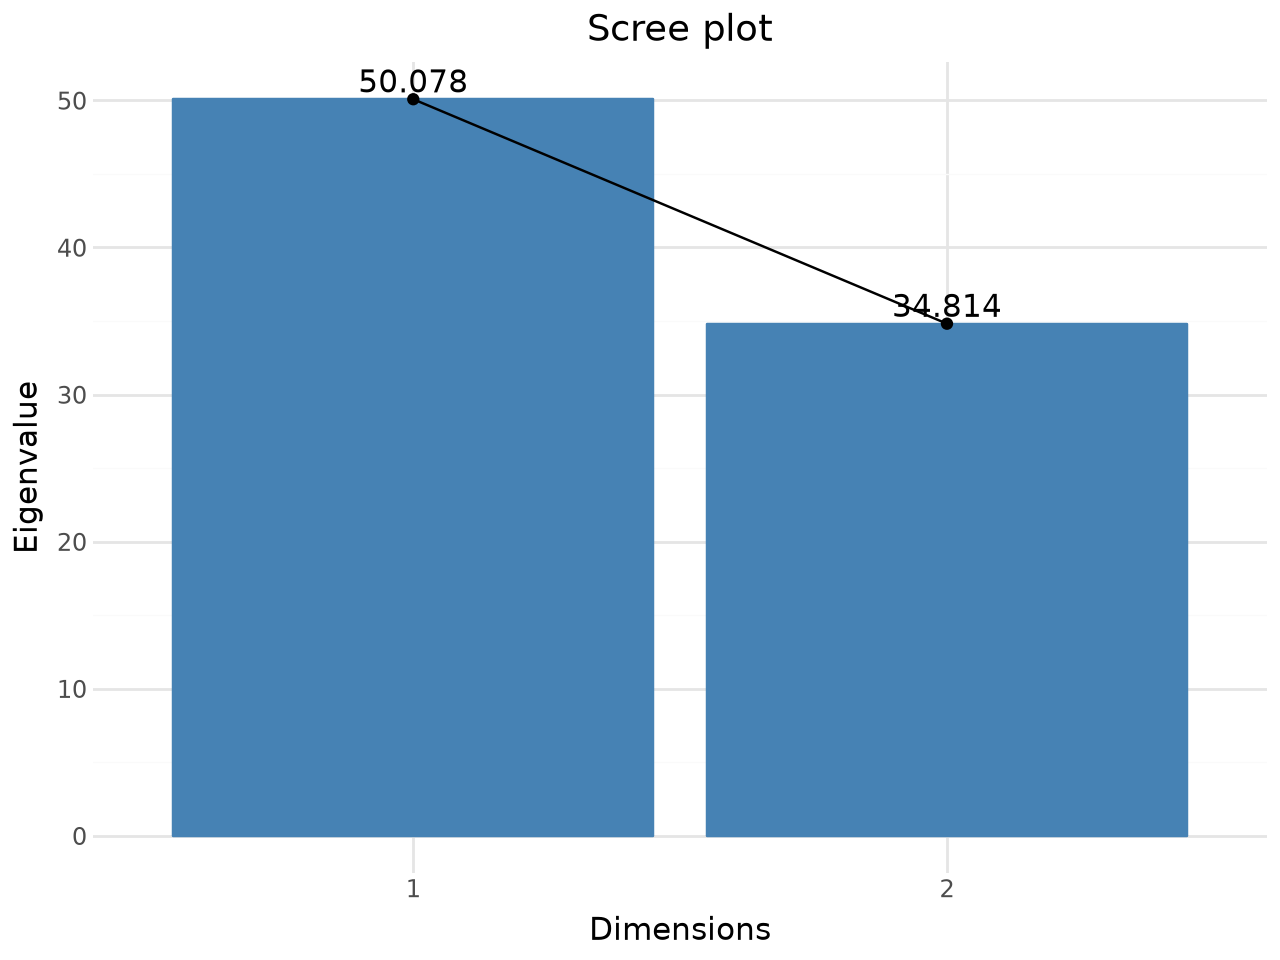

None


In [8]:
# screeplot
p = fviz_screeplot(
    obj = clf,
    choice = "eigenvalue",
    show_labels = True
)
print(p.show())

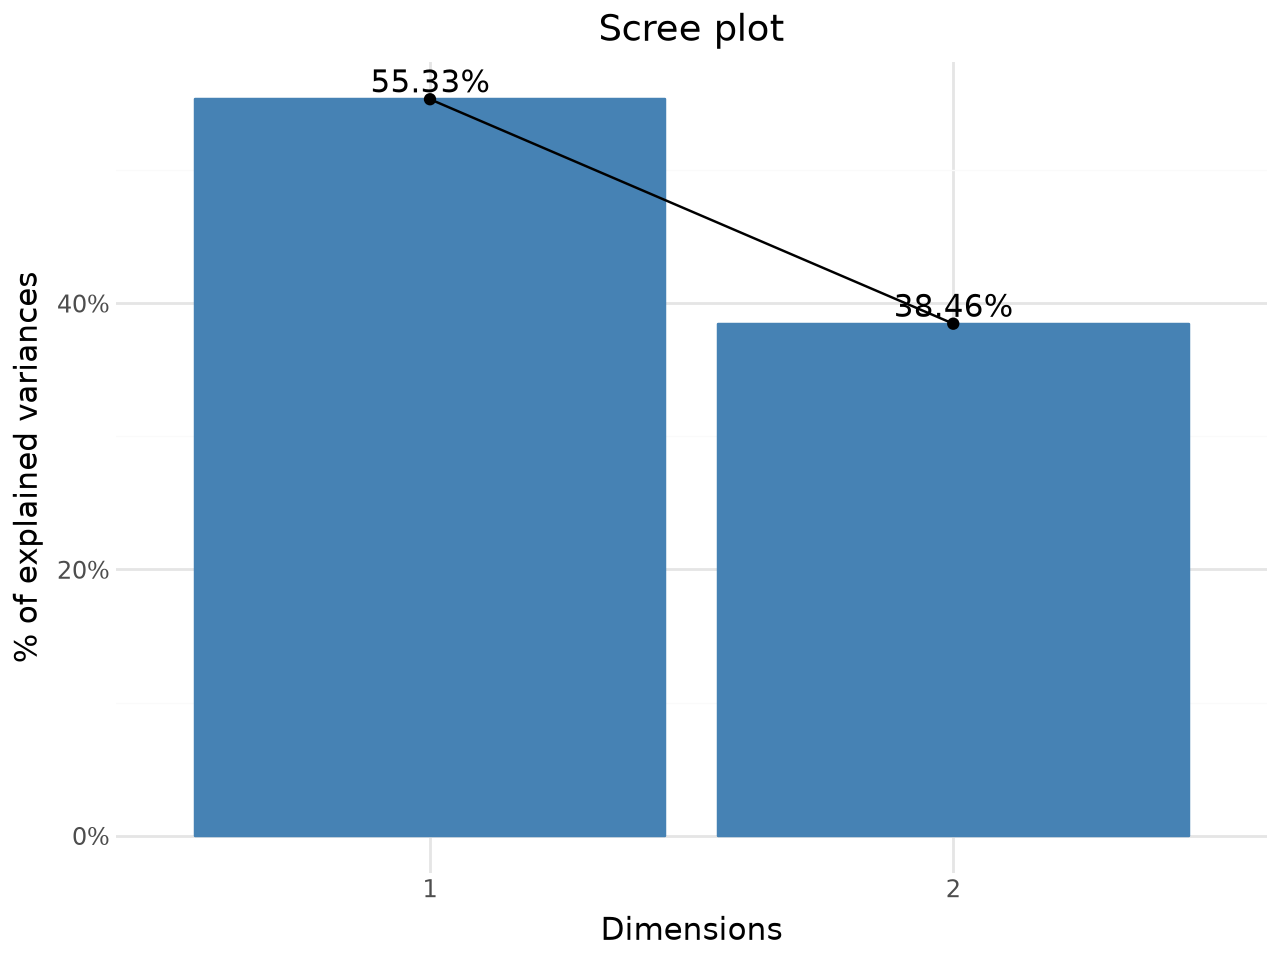

None


In [9]:
# proportion of variance
p = fviz_screeplot(
    obj = clf,
    choice = "proportion",
    show_labels = True
)
print(p.show())

## Variables

In [10]:
#variables
from scientisttools import get_fa
quanti_var = get_fa(clf,"var")
quanti_var._fields

('coord', 'contrib', 'infos')

### Variables coordinates (=loadings)

In [11]:
#variables coordinates (=loadings)
quanti_var.coord

,Dim1,Dim2
cost,-0.966861,-0.095757
size,-0.937494,0.245299
alcohol,-0.918208,-0.156723
reputat,0.189242,0.647424
color,-0.251721,-0.871648
aroma,0.087929,-0.912310
taste,0.064177,-0.966617
rnd1,-0.190895,0.069000
rnd2,0.042544,-0.048128
rnd3,-0.058411,-0.027475


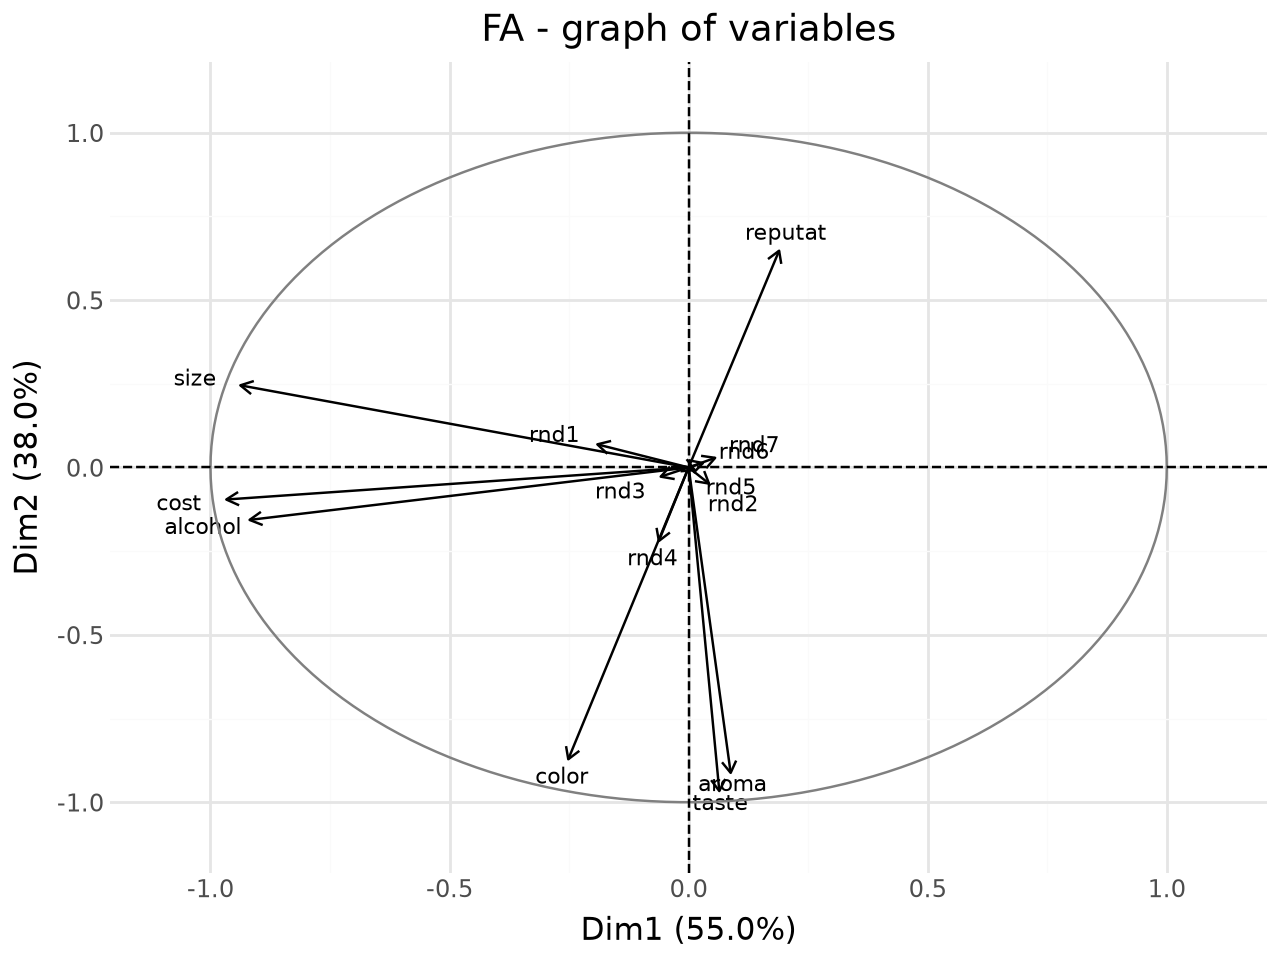

None


In [12]:
# correlation circle
from scientisttools import fviz_fa
p = fviz_fa(
    obj = clf,
    choice = "var",
    repel = True
)
print(p.show())

### Variables contributions

In [13]:
#variables contributions
quanti_var.contrib

,Dim1,Dim2
cost,60.948581,1.174597
size,27.609494,3.713840
alcohol,10.851563,0.621132
reputat,0.068334,1.571395
color,0.291147,6.859075
aroma,0.059680,12.622862
taste,0.164726,73.422153
rnd1,0.004854,0.001246
rnd2,0.000214,0.000538
rnd3,0.000393,0.000171


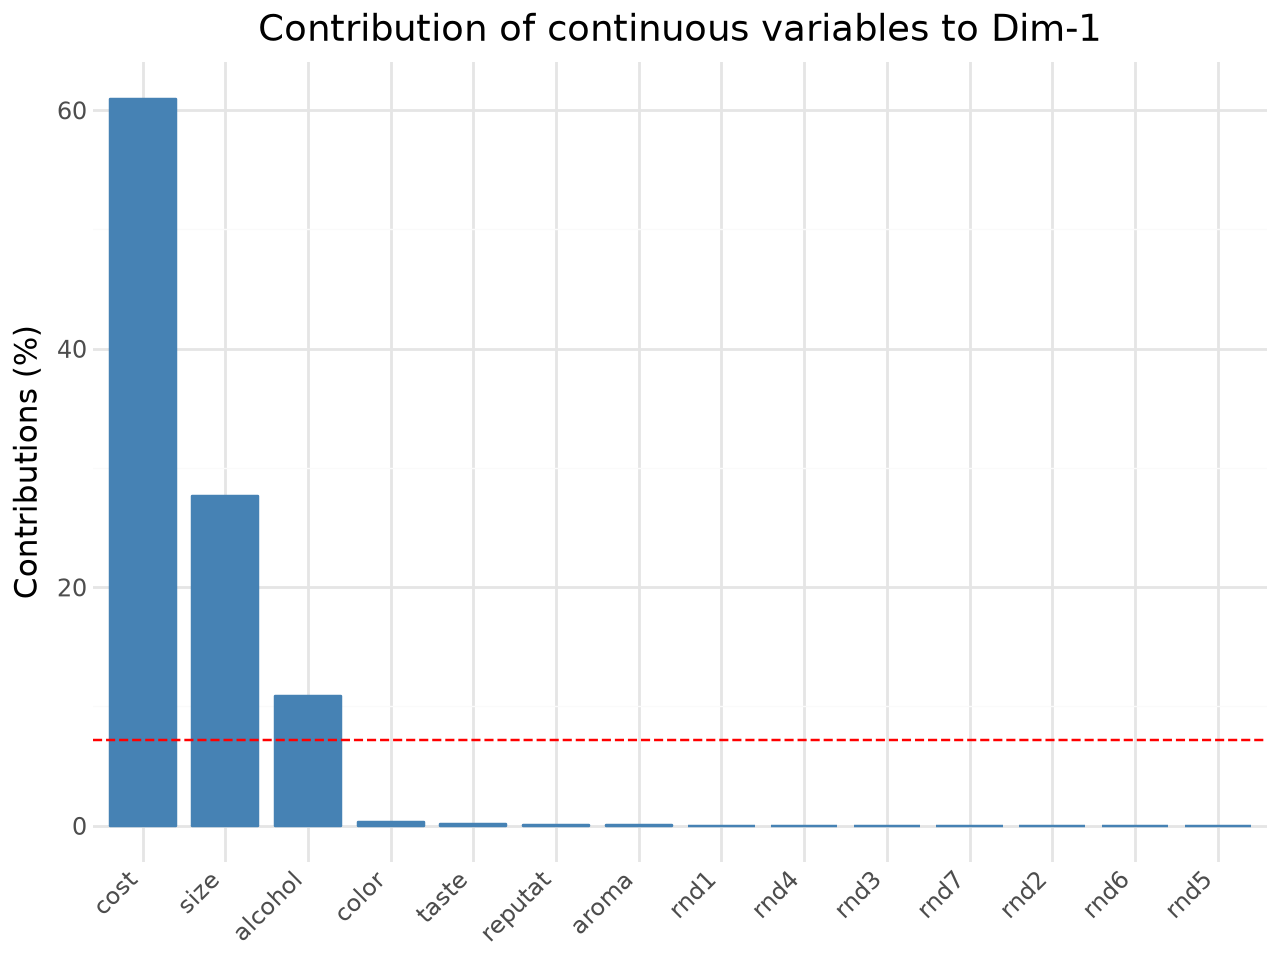

None


In [14]:
# contribution of continuous variables to Dim-1
from scientisttools import fviz_contrib
p = fviz_contrib(clf,"quanti_var")
print(p.show())

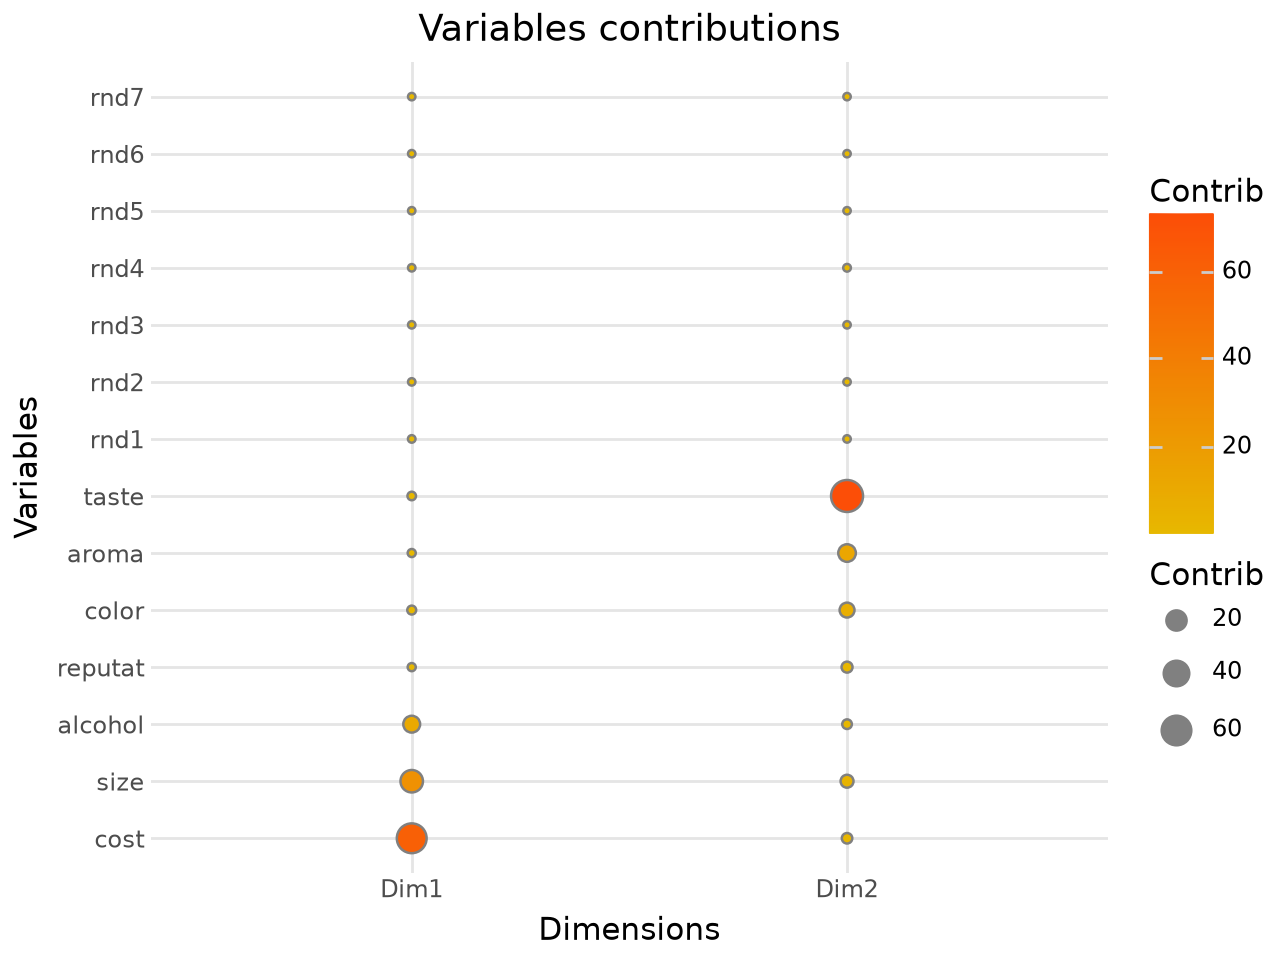

None


In [15]:
# variables contributions
from scientisttools import fviz_corrplot
p = fviz_corrplot(
    X = clf.quanti_var_.contrib,
    title="Variables contributions",
    legend_title="Contrib"
)
print(p.show())

### Variables additionals informations

In [16]:
# variables additionals informations
quanti_var.infos

,Weight,Prior,Final
cost,1.0,0.961050,0.943990
size,1.0,0.943887,0.939067
alcohol,1.0,0.912336,0.867668
reputat,1.0,0.772319,0.454970
color,1.0,0.853280,0.823133
aroma,1.0,0.886801,0.840042
taste,1.0,0.950270,0.938467
rnd1,1.0,0.138258,0.041202
rnd2,1.0,0.084953,0.004126
rnd3,1.0,0.073575,0.004167


## Individuals informations

In [17]:
# individuals informations
ind = get_fa(clf,"ind")
ind._fields

('coord',)

### Individuals coordinates

In [18]:
#individuals coordinates
ind.coord

,Dim1,Dim2
0,0.459294,1.584772
1,-2.375099,-0.176011
2,-0.892645,-0.507876
3,0.857336,-1.290171
4,0.481302,1.216749
...,...,...
94,0.477356,1.206954
95,-0.285022,0.987254
96,0.739941,-0.070497
97,0.652054,-0.438925


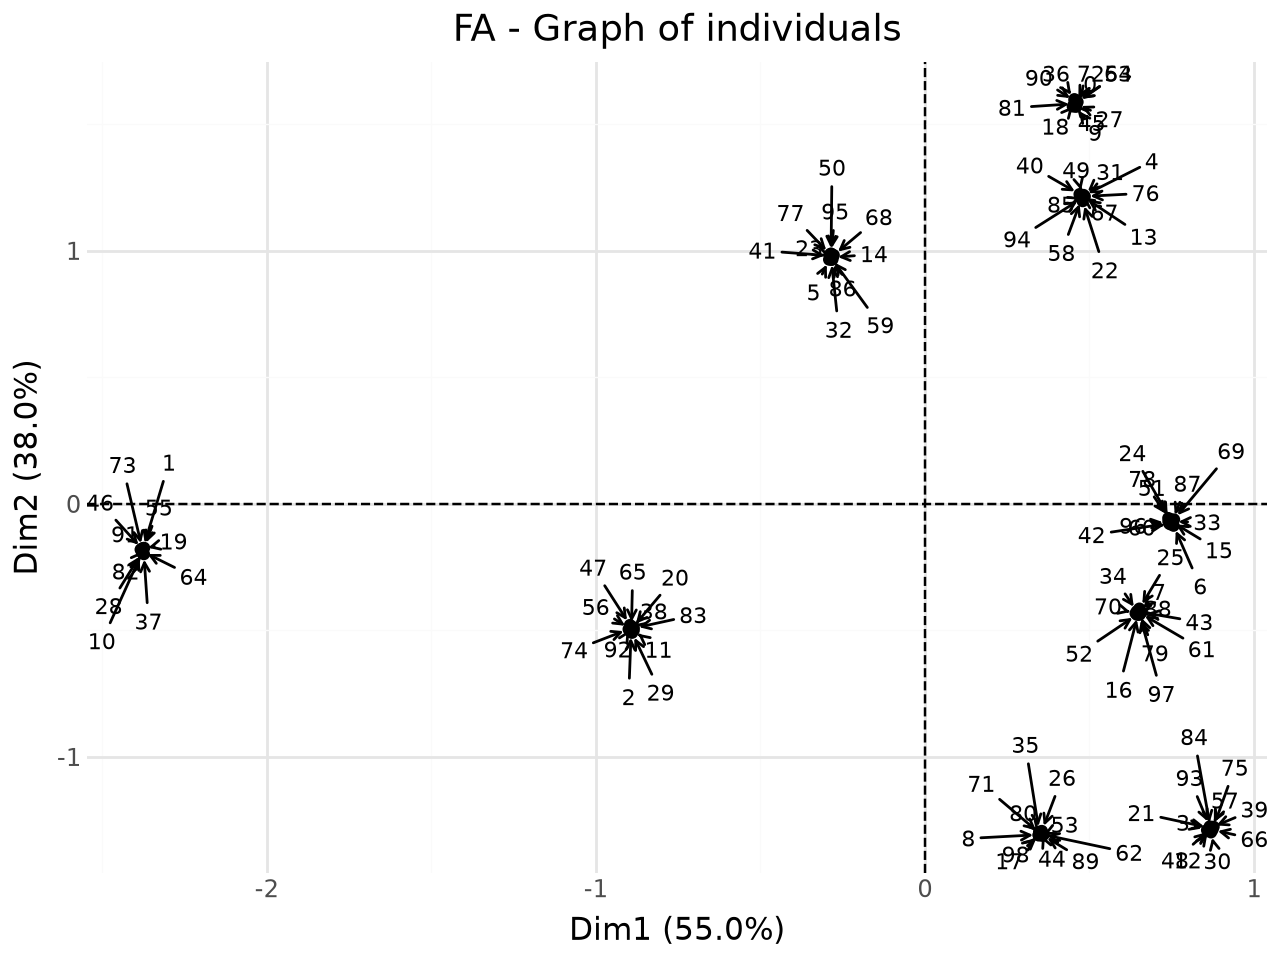

None


In [19]:
# individuals points
p = fviz_fa(
    obj = clf,
    choice = "ind",
    repel = True
)
print(p.show())

## Biplot

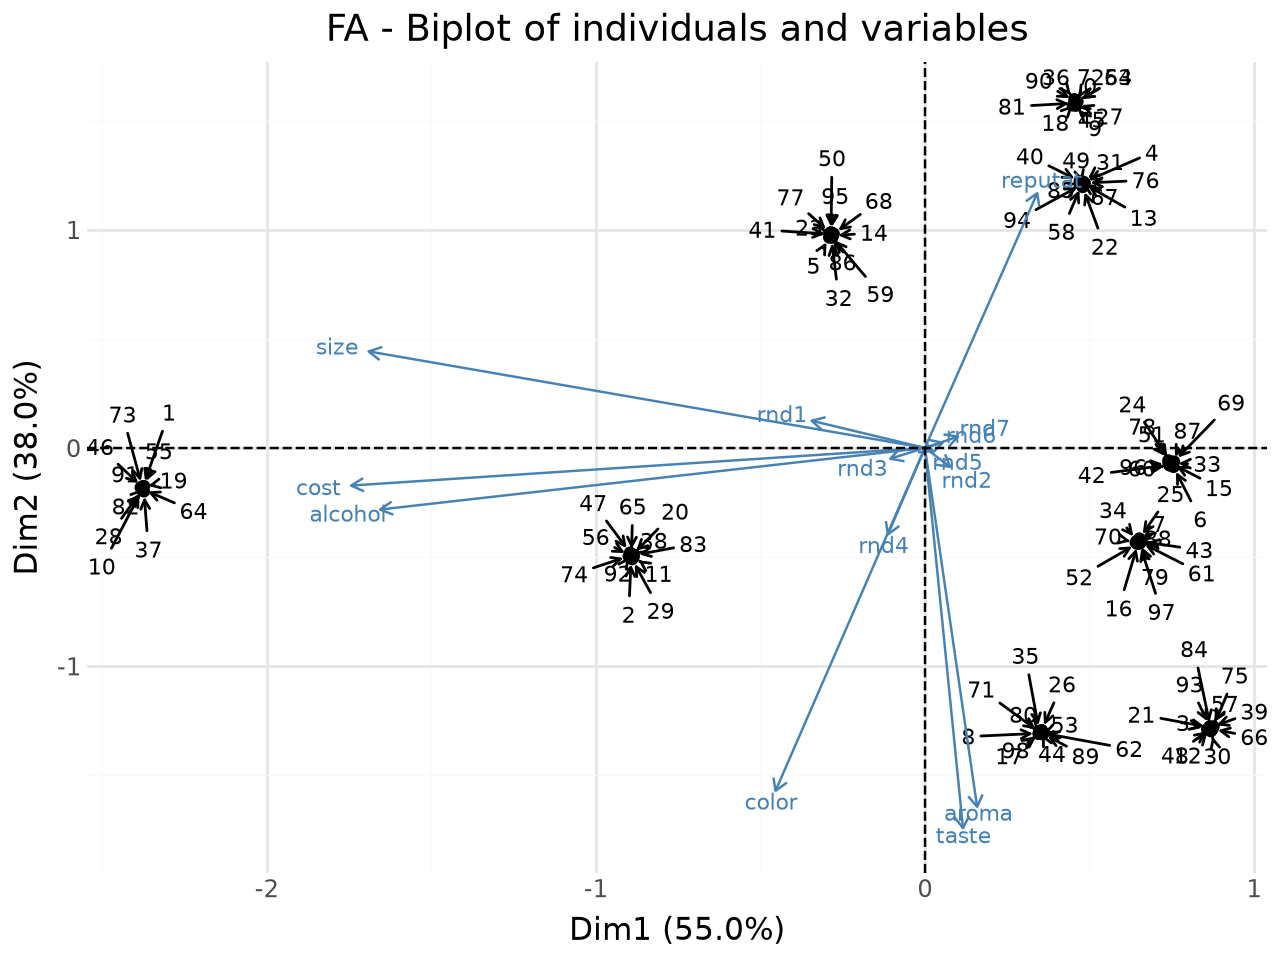

None


In [20]:
# biplot
p = fviz_fa(
    obj = clf,
    choice = "biplot",
    repel_ind = True,
    repel_var = True
)
print(p.show())

## Statistics with FA

In [21]:
# statistics for CA
from scientisttools import statsFA
stats = statsFA(clf)
stats._fields

('corr', 'others')

### Correlation

In [22]:
#correlation
corr = stats.corr
corr._fields

('corrcoef', 'pcorrcoef', 'reconst', 'residual')

#### Pearson correlation matrix

In [23]:
#pearson correlation matrox
corr.corrcoef

,cost,size,alcohol,reputat,color,aroma,taste,rnd1,rnd2,rnd3,rnd4,rnd5,rnd6,rnd7
cost,1.000000,0.878394,0.877019,-0.174783,0.320894,-0.027642,0.053982,0.166062,-0.051740,0.033018,0.101161,-0.001881,-0.022898,-0.062388
size,0.878394,1.000000,0.823668,-0.061234,0.014407,-0.286237,-0.307511,0.206038,-0.035755,0.059759,-0.021006,-0.038331,-0.000748,-0.026847
alcohol,0.877019,0.823668,1.000000,-0.360515,0.397697,0.097678,0.055805,0.182431,-0.028547,0.090211,0.076909,0.000802,-0.080030,-0.081195
reputat,-0.174783,-0.061234,-0.360515,1.000000,-0.523799,-0.521515,-0.626496,0.054200,0.053832,-0.097293,-0.150862,0.038719,-0.047220,0.090954
color,0.320894,0.014407,0.397697,-0.523799,1.000000,0.823244,0.804870,-0.014480,0.106898,0.061969,0.245058,0.024351,-0.085458,0.053949
aroma,-0.027642,-0.286237,0.097678,-0.521515,0.823244,1.000000,0.866073,-0.045175,0.067048,0.043716,0.151902,0.038739,-0.051204,-0.012857
taste,0.053982,-0.307511,0.055805,-0.626496,0.804870,0.866073,1.000000,-0.082160,0.034088,-0.003334,0.206091,-0.012485,0.027340,-0.041157
rnd1,0.166062,0.206038,0.182431,0.054200,-0.014480,-0.045175,-0.082160,1.000000,0.067112,-0.043945,-0.106403,0.187147,0.104980,-0.038058
rnd2,-0.051740,-0.035755,-0.028547,0.053832,0.106898,0.067048,0.034088,0.067112,1.000000,-0.013165,0.063579,0.067021,0.056613,0.070214
rnd3,0.033018,0.059759,0.090211,-0.097293,0.061969,0.043716,-0.003334,-0.043945,-0.013165,1.000000,0.156839,-0.073910,0.071880,0.014219


#### Partial pearson correlation matrix

In [24]:
#partial pearson correlation matrox
corr.pcorrcoef

,cost,size,alcohol,reputat,color,aroma,taste,rnd1,rnd2,rnd3,rnd4,rnd5,rnd6,rnd7
cost,1.000000,0.820162,0.606899,0.695902,0.041644,-0.604287,0.796466,-0.112835,-0.171570,-0.011951,0.134970,0.185414,-0.019552,-0.071346
size,0.820162,1.000000,-0.124221,-0.522308,-0.078193,0.398832,-0.672197,0.117718,0.149532,0.002381,-0.125876,-0.193811,0.089426,0.114562
alcohol,0.606899,-0.124221,1.000000,-0.632505,0.322078,0.402476,-0.592952,0.133218,0.047764,0.012310,-0.072889,-0.083627,-0.082374,-0.104707
reputat,0.695902,-0.522308,-0.632505,1.000000,0.160328,0.416750,-0.767395,0.144765,0.142295,-0.067045,-0.101510,-0.125778,-0.027657,0.032215
color,0.041644,-0.078193,0.322078,0.160328,1.000000,0.352250,0.269313,-0.046095,0.157291,0.048110,0.119991,-0.005908,-0.090712,0.230538
aroma,-0.604287,0.398832,0.402476,0.416750,0.352250,1.000000,0.668571,-0.028785,-0.100662,0.064347,-0.034785,0.161202,-0.056172,-0.070665
taste,0.796466,-0.672197,-0.592952,-0.767395,0.269313,0.668571,1.000000,0.099868,0.082736,-0.088281,-0.059324,-0.193950,0.105593,-0.028986
rnd1,-0.112835,0.117718,0.133218,0.144765,-0.046095,-0.028785,0.099868,1.000000,0.042474,-0.031680,-0.091187,0.219977,0.132345,-0.024035
rnd2,-0.171570,0.149532,0.047764,0.142295,0.157291,-0.100662,0.082736,0.042474,1.000000,-0.028028,0.067000,0.072015,0.077198,0.009493
rnd3,-0.011951,0.002381,0.012310,-0.067045,0.048110,0.064347,-0.088281,-0.031680,-0.028028,1.000000,0.161500,-0.080395,0.098288,-0.001235


#### Reproduced correlation matrix

In [25]:
#reproduced correlation matrox
corr.reconst

,cost,size,alcohol,reputat,color,aroma,taste,rnd1,rnd2,rnd3,rnd4,rnd5,rnd6,rnd7
cost,0.943990,0.882937,0.902787,-0.244967,0.326846,0.002345,0.030511,0.177962,-0.036526,0.059107,0.081201,-0.011638,-0.030209,-0.056392
size,0.882937,0.939067,0.822370,-0.018601,0.022172,-0.306222,-0.297275,0.195889,-0.051691,0.048021,0.004481,-0.013994,-0.024818,-0.044957
alcohol,0.902787,0.822370,0.867668,-0.275230,0.367739,0.062243,0.092563,0.164468,-0.031522,0.057940,0.091560,-0.010526,-0.029559,-0.055446
reputat,-0.244967,-0.018601,-0.275230,0.454970,-0.611962,-0.574012,-0.613666,0.008547,-0.023108,-0.028842,-0.153945,-0.002760,0.014229,0.029113
color,0.326846,0.022172,0.367739,-0.611962,0.823133,0.773080,0.826395,-0.012092,0.031241,0.038652,0.207070,0.003755,-0.019066,-0.039026
aroma,0.002345,-0.306222,0.062243,-0.574012,0.773080,0.840042,0.887497,-0.079735,0.047649,0.019930,0.194861,0.008438,-0.009436,-0.021353
taste,0.030511,-0.297275,0.092563,-0.613666,0.826395,0.887497,0.938467,-0.078948,0.049252,0.022809,0.208264,0.008569,-0.010866,-0.024232
rnd1,0.177962,0.195889,0.164468,0.008547,-0.012092,-0.079735,-0.078948,0.041202,-0.011442,0.009255,-0.003271,-0.003002,-0.004802,-0.008606
rnd2,-0.036526,-0.051691,-0.031522,-0.023108,0.031241,0.047649,0.049252,-0.011442,0.004126,-0.001163,0.007921,0.000932,0.000637,0.000976
rnd3,0.059107,0.048021,0.057940,-0.028842,0.038652,0.019930,0.022809,0.009255,-0.001163,0.004167,0.009669,-0.000529,-0.002112,-0.004030


#### Residual correlation matrix

In [26]:
#residual correlation matrox
corr.residual

,cost,size,alcohol,reputat,color,aroma,taste,rnd1,rnd2,rnd3,rnd4,rnd5,rnd6,rnd7
cost,NaN,-0.004543,-0.025768,0.070184,-0.005952,-0.029987,0.023471,-0.011900,-0.015214,-0.026089,0.019961,0.009757,0.007311,-0.005996
size,-0.004543,NaN,0.001298,-0.042633,-0.007765,0.019985,-0.010236,0.010149,0.015936,0.011738,-0.025486,-0.024336,0.024070,0.018110
alcohol,-0.025768,0.001298,NaN,-0.085285,0.029958,0.035435,-0.036758,0.017964,0.002975,0.032271,-0.014652,0.011327,-0.050471,-0.025750
reputat,0.070184,-0.042633,-0.085285,NaN,0.088163,0.052497,-0.012830,0.045653,0.076940,-0.068451,0.003083,0.041479,-0.061449,0.061841
color,-0.005952,-0.007765,0.029958,0.088163,NaN,0.050164,-0.021525,-0.002388,0.075657,0.023317,0.037988,0.020597,-0.066392,0.092975
aroma,-0.029987,0.019985,0.035435,0.052497,0.050164,NaN,-0.021424,0.034560,0.019399,0.023786,-0.042959,0.030301,-0.041768,0.008496
taste,0.023471,-0.010236,-0.036758,-0.012830,-0.021525,-0.021424,NaN,-0.003212,-0.015163,-0.026144,-0.002173,-0.021054,0.038206,-0.016925
rnd1,-0.011900,0.010149,0.017964,0.045653,-0.002388,0.034560,-0.003212,NaN,0.078555,-0.053200,-0.103132,0.190149,0.109782,-0.029452
rnd2,-0.015214,0.015936,0.002975,0.076940,0.075657,0.019399,-0.015163,0.078555,NaN,-0.012002,0.055658,0.066089,0.055976,0.069238
rnd3,-0.026089,0.011738,0.032271,-0.068451,0.023317,0.023786,-0.026144,-0.053200,-0.012002,NaN,0.147171,-0.073381,0.073992,0.018249


### Others statistics

In [27]:
# others statistics
others = stats.others
others._fields

('vaccounted', 'explained_variance', 'communalities', 'inertia')

#### Variances accounted

In [28]:
#variances accounted
others.vaccounted

,Dim1,Dim2
Original,3.386557,2.794665
Common,50.078209,34.814480
SS loadings,2.817522,3.096606
Proportion Var (%),20.125155,22.118617
Cumulative Var (%),20.125155,42.243772
Proportion Explained (%),47.640526,52.359474
Cumulative Proportion (%),47.640526,100.000000


#### Explained variance

In [29]:
# explained variance
others.explained_variance

,Weighted,Unweighted,R2
Dim1,50.078209,2.817522,0.980422
Dim2,34.814480,3.096606,0.972078


#### Communalities

In [30]:
#communalities
round(others.communalities,4)

5.9141

#### Inertia

In [31]:
#inertia
round(others.inertia,4)

7.0137

## Others elements

### Summary

In [ ]:
# summary
from scientisttools import summary
summary(clf)